In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytz

In [8]:
def preprocess_RAW(file_path):
    sensor = pd.read_csv(file_path, parse_dates=['timestamp'])
    sensor = sensor[['timestamp_local','rh','temp','pm25']].dropna(subset=['pm25'])
    sensor.rename(columns={'timestamp_local':'time'}, inplace=True)
    
    sensor['time'] = pd.to_datetime(sensor['time'])
    est = pytz.timezone('US/Eastern')
    sensor['time'] = sensor['time'].dt.tz_convert(est)
    sensor['time'] = sensor['time'].dt.strftime('%Y-%m-%d %H:%M:%S')
    sensor['time'] = pd.to_datetime(sensor['time'])
    sensor['day'] = sensor['time'].dt.date
    sensor['dayhour'] = sensor['time'].dt.strftime('%Y-%m-%d %H')

    sensor = sensor.groupby('dayhour').agg(
        pm25=('pm25', lambda x: x.mean(skipna=True)),
    ).reset_index()
    sensor = sensor.sort_values(by='dayhour')
    return sensor[['dayhour', 'pm25']]

def preprocess_PRED(file_path):
    pred = pd.read_csv(file_path)
    pred = pred[['dayhour','corrected_PM25h']].dropna(subset=['corrected_PM25h'])
    pred.rename(columns={'corrected_PM25h':'pm25'}, inplace=True)

    pred = pred.sort_values('dayhour')
    return pred[['dayhour', 'pm25']]



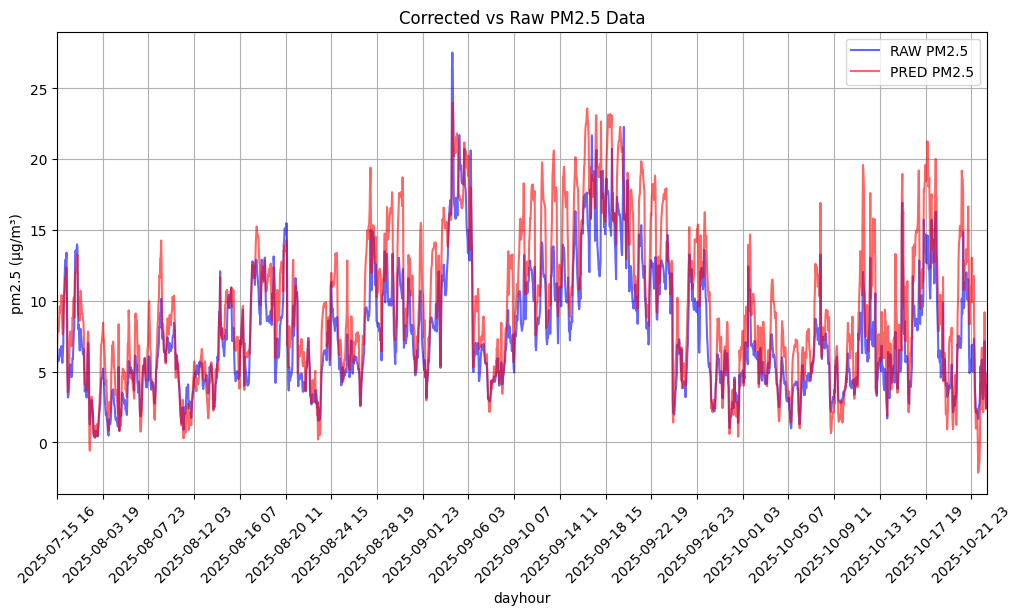

In [9]:
raw_data = preprocess_RAW('../presentationData/current-MOD-00589-RAW.csv')
pred_data = preprocess_PRED('../presentationData/hMOD-00589-PRED.csv')

plt.figure(figsize=(12, 6))
plt.plot(raw_data['dayhour'], raw_data['pm25'], label='RAW PM2.5', color='blue', alpha=0.6)
plt.plot(pred_data['dayhour'], pred_data['pm25'], label='PRED PM2.5', color='red', alpha=0.6)

# Add title and labels
plt.xlabel('dayhour')
plt.ylabel(f'pm2.5 (μg/m\u00B3)')
plt.xticks(pred_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(pred_data['dayhour'].min(), pred_data['dayhour'].max())
plt.legend()
plt.title("Corrected vs Raw PM2.5 Data")
plt.grid()
plt.show() # plot with no raw data
